# Lab 2 — Biological Binary Classification, Logistic Regression, and Regularization
# Group 8 Members: Rami Abou Fakhr, Amir H. Q. Selakjan, Alison Mae Worth
Author: Dario Righelli

This notebook is designed for a Master's degree course in Quantitative and Computational Biology.

In Lab 1, we used a real biological data matrix to study linear regression, the Mean Squared Error (MSE), and Gradient Descent (GD). In this lab, we move from **regression** to **binary classification**.

We use a real single-cell ribonucleic acid sequencing (single-cell RNA-seq) dataset and train a logistic regression model to classify cells as:

- `1`: neuronal cell
- `0`: non-neuronal cell

The model uses gene expression features.

## Expected input file

This notebook expects a preprocessed comma-separated values (CSV) file called:

```text
zeisel_neuron_classification.csv
```

The expected structure is:

```text
cell_id
cell_type
label
gene_001__...
gene_002__...
...
```

where `label = 1` means neuronal and `label = 0` means non-neuronal.

## Matrix orientation reminder

In many bioinformatics workflows, expression matrices are stored as:

```text
rows = genes
columns = cells
```

In machine learning, we usually need:

```text
rows = cells
columns = features
```

Therefore, the expression matrix is often transposed before being used as a machine learning input matrix.

## Learning goals

By the end of this notebook, you should be able to:

- load a biological classification dataset
- represent a gene expression matrix in machine learning format
- compute linear classification scores
- use the sigmoid function to convert scores into probabilities
- implement logistic regression from scratch using NumPy
- compute Binary Cross-Entropy (BCE) loss
- train logistic regression with Gradient Descent (GD)
- evaluate a binary classifier
- understand L2 regularization
- inspect coefficients in a biological context


In [2]:
# Section 0 - Setup
# pandas is used for table import.
# NumPy is used for numerical computation.
# Matplotlib is used for visualization.

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


ModuleNotFoundError: No module named 'matplotlib'

## Section 1 — Load the biological classification dataset

The target is binary:

- `1`: neuronal cell
- `0`: non-neuronal cell

This is different from Lab 1, where the target was continuous. Here, the goal is to assign each cell to one of two biological classes.


In [ ]:
# Section 1 - Load the dataset

data_path = Path("zeisel_neuron_classification.csv")

if not data_path.exists():
    raise FileNotFoundError(
        "Could not find 'zeisel_neuron_classification.csv'. "
        "Place it in the same directory as this notebook or update data_path."
    )

data = pd.read_csv(data_path)

print("Dataset shape:", data.shape)
display(data.head())

required_columns = ["cell_id", "cell_type", "label"]
missing_columns = [col for col in required_columns if col not in data.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

gene_columns = [col for col in data.columns if col.startswith("gene_")]
print("Number of gene expression features:", len(gene_columns))
print("First 10 gene feature columns:")
print(gene_columns[:10])

X_raw = data[gene_columns].to_numpy(dtype=float)
y = data["label"].to_numpy(dtype=int)

print("\nShape of X_raw:", X_raw.shape)
print("Shape of y:", y.shape)
print("\nUnique labels and counts:")
for label, count in zip(*np.unique(y, return_counts=True)):
    print(f"label {label}: {count} cells")


Dataset shape: (3005, 103)


,cell_id,cell_type,label,gene_001__Plp1,gene_002__Trf,gene_003__Mal,gene_004__Apod,gene_005__Mog,gene_006__Mbp,gene_007__Car2,...,gene_091__Pdlim2,gene_092__Eno2,gene_093__Vsnl1,gene_094__Ncdn,gene_095__Scn2a1,gene_096__Rasgrp1,gene_097__Gstp1,gene_098__Npy,gene_099__Rgs4,gene_100__Gabra1
0,1772071015_C02,interneurons,1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,3.911539,4.302407,2.811624,3.174352,1.878092,3.911539,6.858766,0.000000,4.147656
1,1772071017_G12,interneurons,1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,4.410823,5.771367,2.639523,3.434108,0.725878,0.725878,0.000000,3.248047,5.017366
2,1772071017_A05,interneurons,1,0.544784,0.0,0.0,0.0,0.0,0.0,1.719845,...,0.0,3.210769,3.742831,2.978567,3.586314,0.000000,1.907972,5.808803,0.000000,3.791445
3,1772071014_B06,interneurons,1,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,4.054166,6.037357,2.326120,3.434741,1.225388,2.856957,0.000000,0.000000,5.935889
4,1772067065_H06,interneurons,1,0.756446,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,3.951942,4.569715,2.703675,4.242025,0.000000,2.152709,0.000000,0.000000,5.811109


Number of gene expression features: 100
First 10 gene feature columns:
['gene_001__Plp1', 'gene_002__Trf', 'gene_003__Mal', 'gene_004__Apod', 'gene_005__Mog', 'gene_006__Mbp', 'gene_007__Car2', 'gene_008__Meg3', 'gene_009__Cnp', 'gene_010__Enpp2']

Shape of X_raw: (3005, 100)
Shape of y: (3005,)

Unique labels and counts:
label 0: 1377 cells
label 1: 1628 cells


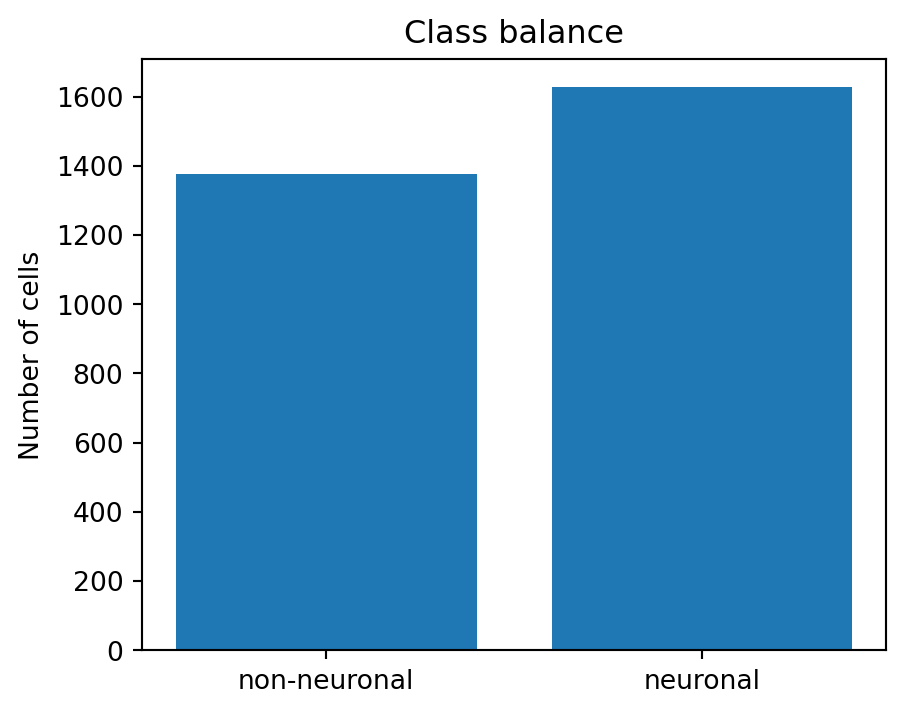

In [ ]:
# Section 1 - Visualize class balance

labels = ["non-neuronal", "neuronal"]
counts = [np.sum(y == 0), np.sum(y == 1)]

plt.figure(figsize=(5, 4))
plt.bar(labels, counts)
plt.ylabel("Number of cells")
plt.title("Class balance")
plt.show()


The class balance plot tells us whether the two biological groups are equally represented. If one class is much larger than the other, accuracy alone can be misleading.

### Exercises for Section 1

**Exercise 1.1** Print the number of cells and the number of gene features.

**Exercise 1.2** Print how many cells are neuronal and how many are non-neuronal.

**Exercise 1.3** Answer in words: what does one row of `X_raw` represent?

**Exercise 1.4** Answer in words: what does one column of `X_raw` represent?


In [ ]:
# Exercises for Section 1

# Exercise 1.1 - Number of cells and gene features
print("Number of cells:", X_raw.shape[0])
print("Number of gene features:", X_raw.shape[1])

# Exercise 1.2 - Neuronal and non-neuronal counts
print("Neuronal cells:", np.sum(y == 1))
print("Non-neuronal cells:", np.sum(y == 0))


**Exercise 1.3** One row of `X_raw` represents one cell.

**Exercise 1.4** One column of `X_raw` represents one gene.

## Section 2 — Data exploration and feature scaling

The file contains selected variable genes. Each gene is a feature. Because gene expression features can have different scales, we standardize them before training.

For each feature, standardization computes:

$$
x_{std} = \frac{x - \mu}{\sigma}
$$

where $\mu$ is the feature mean and $\sigma$ is the feature standard deviation.


In [ ]:
# Section 2 - Basic feature summaries

feature_means = X_raw.mean(axis=0)
feature_stds = X_raw.std(axis=0)

print("Mean of the first 5 gene features:")
print(feature_means[:5])
print("\nStandard deviation of the first 5 gene features:")
print(feature_stds[:5])


Mean of the first 5 gene features:
[3.88112772 2.2605409  2.29886397 1.88782965 1.81309992]

Standard deviation of the first 5 gene features:
[3.86975498 3.12250719 2.99514857 2.7621676  2.66782099]


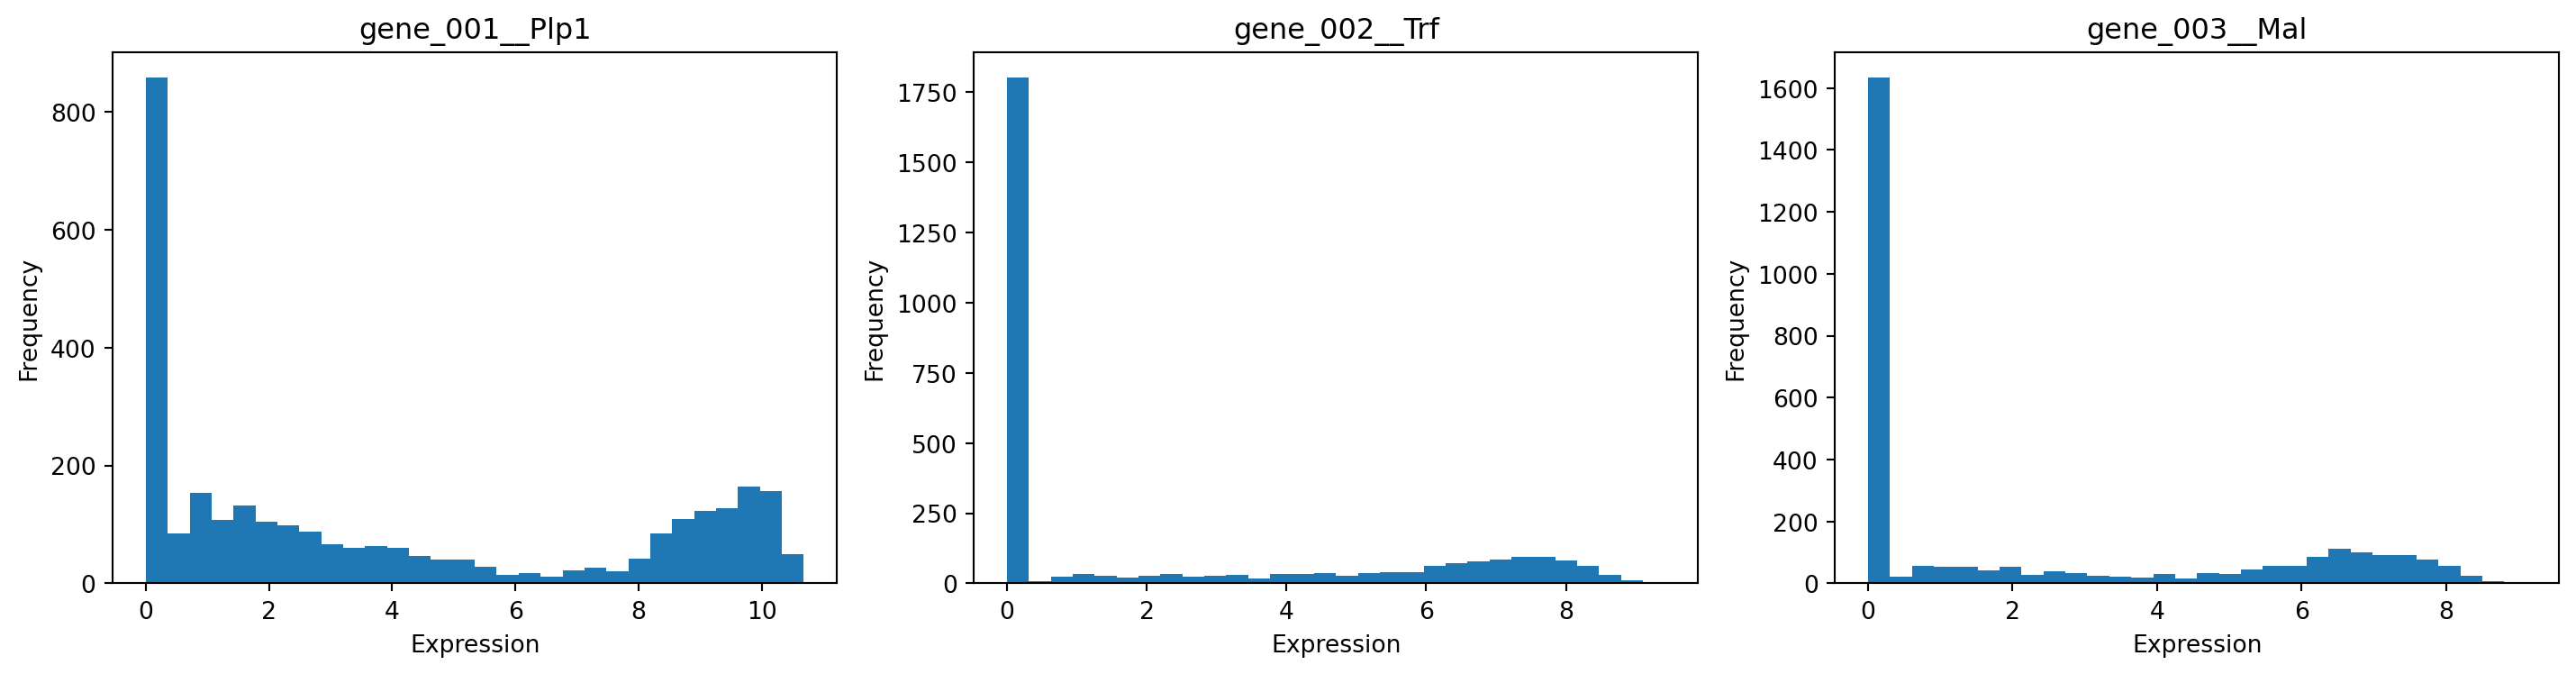

In [ ]:
# Section 2 - Visualize distributions for a few genes

selected_gene_indices = [0, 1, 2]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, idx in zip(axes, selected_gene_indices):
    ax.hist(X_raw[:, idx], bins=30)
    ax.set_title(gene_columns[idx])
    ax.set_xlabel("Expression")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


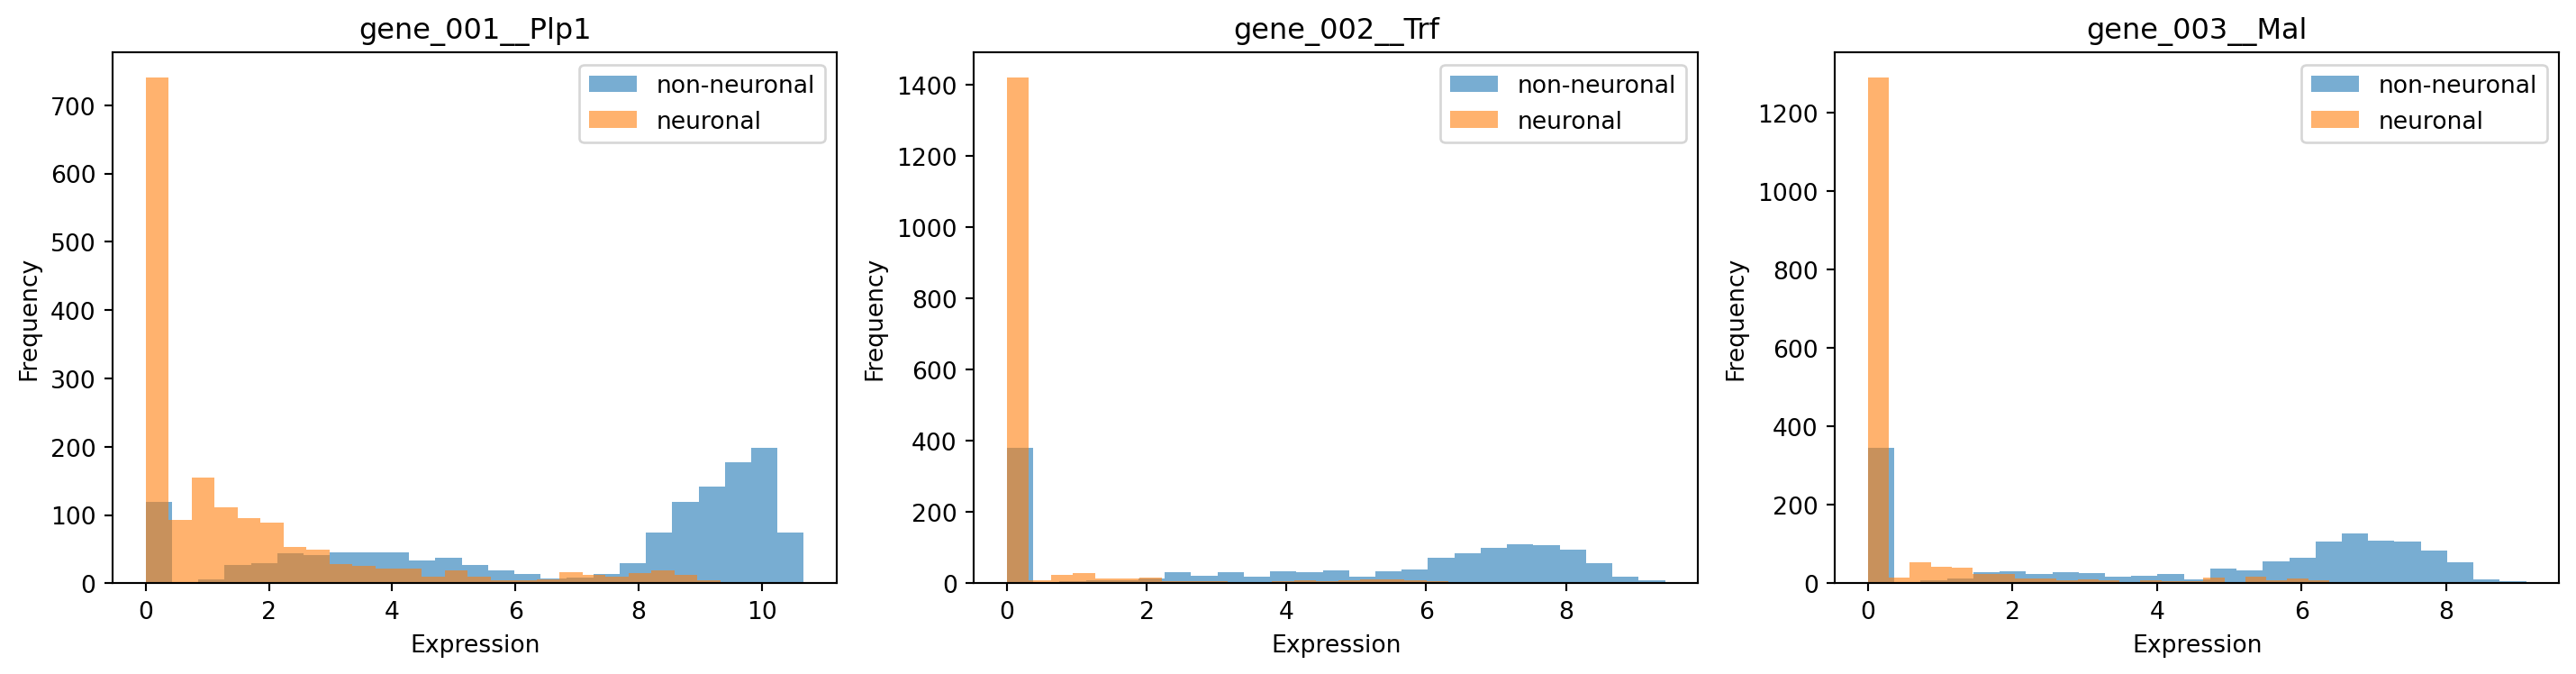

In [ ]:
# Section 2 - Compare gene distributions by class

selected_gene_indices = [0, 1, 2]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, idx in zip(axes, selected_gene_indices):
    ax.hist(X_raw[y == 0, idx], bins=25, alpha=0.6, label="non-neuronal")
    ax.hist(X_raw[y == 1, idx], bins=25, alpha=0.6, label="neuronal")
    ax.set_title(gene_columns[idx])
    ax.set_xlabel("Expression")
    ax.set_ylabel("Frequency")
    ax.legend()
    
plt.tight_layout()
plt.show()



If the expression distributions differ between classes, that gene may be informative for classification. Logistic regression combines information from many genes rather than relying on one feature.


In [ ]:
# Section 2 - Standardize the gene expression matrix

eps = 1e-8
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X = (X_raw - X_mean) / (X_std + eps)

print("Mean of first 5 standardized features:")
print(X[:, :5].mean(axis=0))
print("\nStandard deviation of first 5 standardized features:")
print(X[:, :5].std(axis=0))


Mean of first 5 standardized features:
[ 3.02660466e-16  7.56651166e-17  3.78325583e-17  3.78325583e-17
 -1.51330233e-16]

Standard deviation of first 5 standardized features:
[1. 1. 1. 1. 1.]


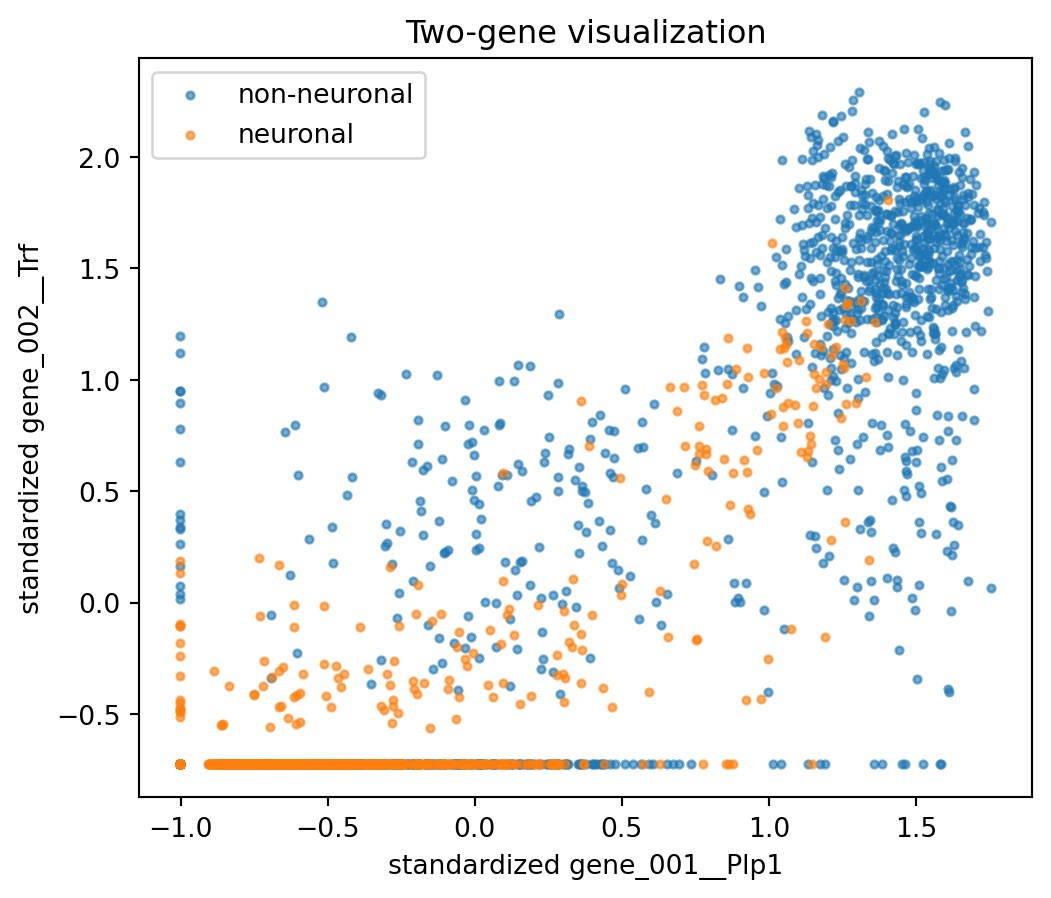

In [ ]:
# Section 2 - Two-gene visualization

gene_a = 0
gene_b = 1

plt.figure(figsize=(6, 5))
plt.scatter(X[y == 0, gene_a], X[y == 0, gene_b], s=8, alpha=0.6, label="non-neuronal")
plt.scatter(X[y == 1, gene_a], X[y == 1, gene_b], s=8, alpha=0.6, label="neuronal")
plt.xlabel(f"standardized {gene_columns[gene_a]}")
plt.ylabel(f"standardized {gene_columns[gene_b]}")
plt.title("Two-gene visualization")
plt.legend()
plt.show()


The two-gene visualization shows a partial separation between neuronal and non-neuronal cells. Non-neuronal cells tend to have higher standardized values of Trf, while neuronal cells are more concentrated at lower Trf values. However, the two classes still overlap, indicating that these two genes alone are not sufficient for perfect classification and that the full model should combine information from multiple genes.

### Exercises for Section 2

**Exercise 2.1** Compute the mean and standard deviation of each gene feature.

**Exercise 2.2** Standardize `X_raw` manually and store it in a new variable.

**Exercise 2.3** Plot the distribution of one gene before and after standardization.

**Exercise 2.4** Look at one gene distribution by class. Does it look informative for classification?


In [ ]:
# Exercises for Section 2

# Exercise 2.1 - Mean and standard deviation of each gene feature
gene_means = X_raw.mean(axis=0)
gene_stds = X_raw.std(axis=0)
print("Mean of the first 5 gene features:")
print(gene_means[:5])
print("\nStandard deviation of the first 5 gene features:")
print(gene_stds[:5])

# Exercise 2.2 - Standardize X_raw manually
eps = 1e-8
X_standardized = (X_raw - gene_means) / (gene_stds + eps)
print("\nShape of X_standardized:", X_standardized.shape)

# Exercise 2.3 - Plot one gene before and after standardization
gene_idx = 0

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(X_raw[:, gene_idx], bins=30)
axes[0].set_title("Before standardization")
axes[0].set_xlabel("Expression")
axes[0].set_ylabel("Frequency")

axes[1].hist(X_standardized[:, gene_idx], bins=30)
axes[1].set_title("After standardization")
axes[1].set_xlabel("Expression")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Exercise 2.4 - Look at one gene distribution by class
gene_idx = 0

plt.figure(figsize=(6, 4))
plt.hist(X_raw[y == 0, gene_idx], bins=25, alpha=0.6, label="non-neuronal")
plt.hist(X_raw[y == 1, gene_idx], bins=25, alpha=0.6, label="neuronal")
plt.title(gene_columns[gene_idx])
plt.xlabel("Expression")
plt.ylabel("Frequency")
plt.legend()
plt.show()


**Exercise 2.4** The two classes have different distributions for this gene, so it looks informative for classification.

## Section 3 — Train/test split

We split the data into:

- training set: used to learn the parameters
- test set: used to evaluate the classifier on unseen cells

We implement a simple stratified split manually to preserve approximately the same class proportions in training and test data.


In [ ]:
# Section 3 - Stratified train/test split

def stratified_train_test_split(X, y, test_fraction=0.25, seed=42):
    rng = np.random.default_rng(seed)
    train_indices = []
    test_indices = []

    for label in np.unique(y):
        label_indices = np.where(y == label)[0]
        rng.shuffle(label_indices)
        n_test = int(np.round(test_fraction * len(label_indices)))
        test_indices.extend(label_indices[:n_test])
        train_indices.extend(label_indices[n_test:])

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)
    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return X[train_indices], X[test_indices], y[train_indices], y[test_indices], train_indices, test_indices

X_train, X_test, y_train, y_test, train_idx, test_idx = stratified_train_test_split(
    X, y, test_fraction=0.25, seed=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTraining class counts:", np.unique(y_train, return_counts=True))
print("Test class counts:", np.unique(y_test, return_counts=True))


X_train shape: (2254, 100)
X_test shape: (751, 100)

Training class counts: (array([0, 1]), array([1033, 1221]))
Test class counts: (array([0, 1]), array([344, 407]))


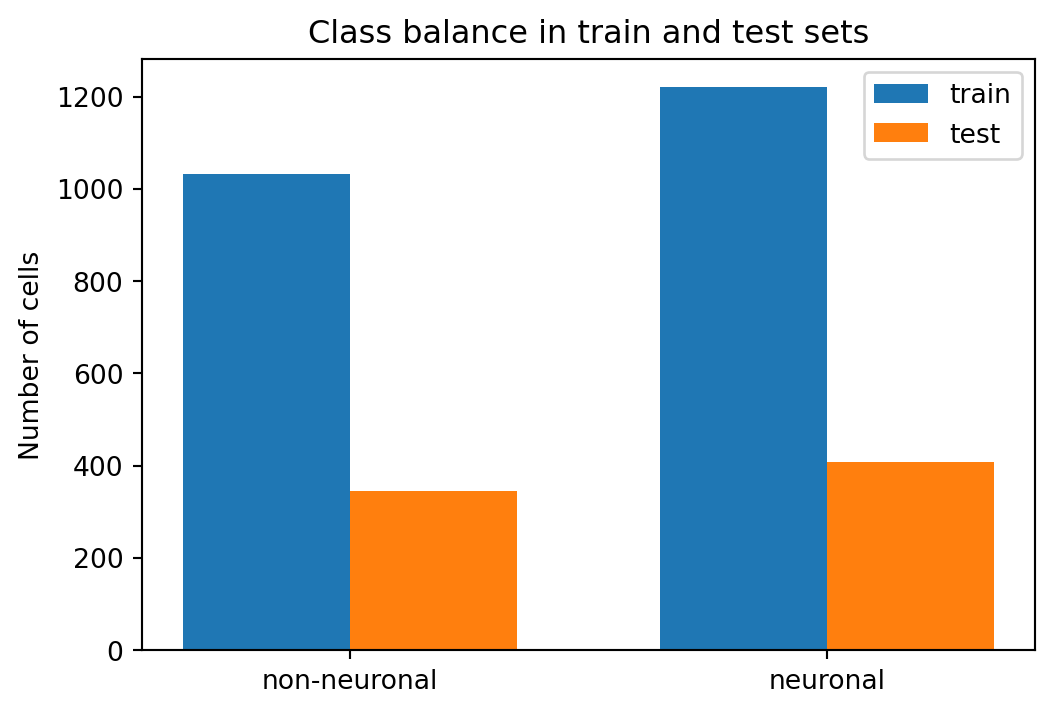

In [ ]:
# Section 3 - Visualize class balance in train and test sets

train_counts = [np.sum(y_train == 0), np.sum(y_train == 1)]
test_counts = [np.sum(y_test == 0), np.sum(y_test == 1)]

x_pos = np.arange(2)
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x_pos - width / 2, train_counts, width, label="train")
plt.bar(x_pos + width / 2, test_counts, width, label="test")
plt.xticks(x_pos, ["non-neuronal", "neuronal"])
plt.ylabel("Number of cells")
plt.title("Class balance in train and test sets")
plt.legend()
plt.show()


### Exercises for Section 3

**Exercise 3.1** Compute the percentage of neuronal cells in the full dataset, training set, and test set.

**Exercise 3.2** Why is it useful to preserve class proportions in train and test sets?

**Exercise 3.3** What could go wrong if the test set contains almost only one class?


In [ ]:
# Exercises for Section 3

# Exercise 3.1 - Percentage of neuronal cells in full, train, and test sets
pct_full = np.sum(y == 1) / len(y) * 100
pct_train = np.sum(y_train == 1) / len(y_train) * 100
pct_test = np.sum(y_test == 1) / len(y_test) * 100

print("Neuronal cells in full dataset:", pct_full, "%")
print("Neuronal cells in training set:", pct_train, "%")
print("Neuronal cells in test set:", pct_test, "%")


**Exercise 3.2** Preserving class proportions keeps both classes equally represented in the train and test sets, so the model sees both classes during training and the test set is a fair evaluation of how the model performs on the real class balance.

**Exercise 3.3** If the test set contains almost only one class, accuracy can look high even when the model is bad, because predicting the majority class alone would give a high score. We would not be able to measure how well the model handles the other class.

## Section 4 — Linear scores and threshold classifiers

A linear classifier first computes a score:

$$
s = Xw + b
$$

Then it assigns a class using a threshold:

$$
\hat{y} =
\begin{cases}
1 & \text{if } s \geq 0 \\
0 & \text{if } s < 0
\end{cases}
$$

The score is not a probability. It can be any real number. This motivates logistic regression.


In [ ]:
# Section 4 - Linear scores with arbitrary parameters
# These weights are not learned from data.
# We set the first two weights to 1 and -1 only to create a simple example:
# score = gene_001 - gene_002.
# All other genes have weight 0 and do not contribute to the score.

w_example = np.zeros(X_train.shape[1])
w_example[0] = 1.0
w_example[1] = -1.0
b_example = 0.0

scores_example = X_train @ w_example + b_example
y_pred_example = (scores_example >= 0).astype(int)

print("First 10 scores:")
print(scores_example[:10])
print("\nFirst 10 predicted labels:")
print(y_pred_example[:10])
print("\nFirst 10 true labels:")
print(y_train[:10])


First 10 scores:
[-0.2789883   0.76660836 -0.2789883   0.29027433 -0.01671054 -0.04491821
 -0.22553548 -0.2789883   0.09096722 -0.2789883 ]

First 10 predicted labels:
[0 1 0 1 0 0 0 0 1 0]

First 10 true labels:
[1 0 1 0 1 0 0 1 0 1]


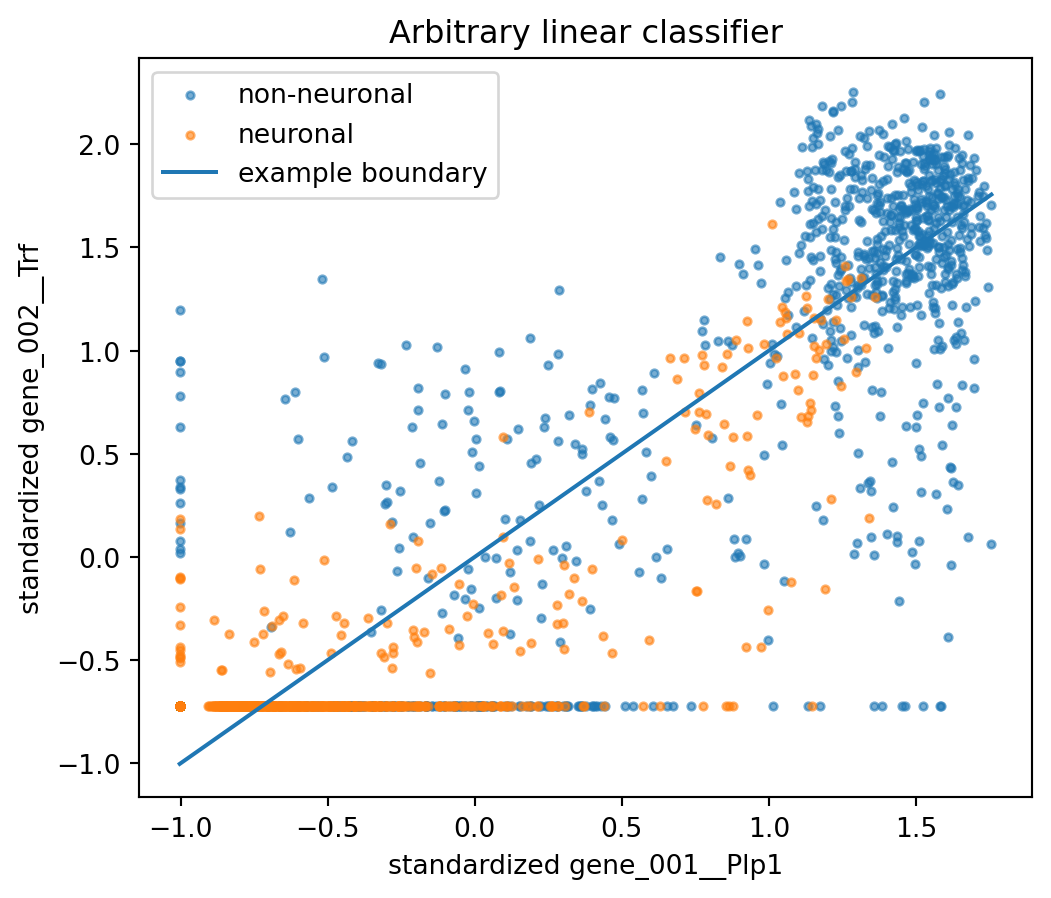

In [ ]:
# Section 4 - Visualize arbitrary linear decision boundary using two genes

plt.figure(figsize=(6, 5))
plt.scatter(X_train[y_train == 0, gene_a], X_train[y_train == 0, gene_b], s=8, alpha=0.6, label="non-neuronal")
plt.scatter(X_train[y_train == 1, gene_a], X_train[y_train == 1, gene_b], s=8, alpha=0.6, label="neuronal")

x_values = np.linspace(X_train[:, gene_a].min(), X_train[:, gene_a].max(), 100)
if abs(w_example[gene_b]) > 1e-12:
    y_boundary = -(w_example[gene_a] * x_values + b_example) / w_example[gene_b]
    plt.plot(x_values, y_boundary, label="example boundary")

plt.xlabel(f"standardized {gene_columns[gene_a]}")
plt.ylabel(f"standardized {gene_columns[gene_b]}")
plt.title("Arbitrary linear classifier")
plt.legend()
plt.show()


The line separates the two-dimensional feature space into two regions. However, the boundary is produced from arbitrary parameters, not learned parameters.

### Exercises for Section 4

**Exercise 4.1** Compute linear scores using another pair of arbitrary weights.

**Exercise 4.2** Convert scores into predicted labels using a threshold at zero.

**Exercise 4.3** Why is the raw score not a probability?

**Exercise 4.4** In two dimensions, what geometric object is the decision boundary?


In [ ]:
# Exercises for Section 4

# Exercise 4.1 - Linear scores with another pair of arbitrary weights
# Here we use gene_003 and gene_004 with weights 0.5 and -0.5.
# All other genes have weight 0.

w_example2 = np.zeros(X_train.shape[1])
w_example2[2] = 0.5
w_example2[3] = -0.5
b_example2 = 0.0

scores_example2 = X_train @ w_example2 + b_example2

print("First 10 scores:")
print(scores_example2[:10])

# Exercise 4.2 - Convert scores into predicted labels using threshold at zero
y_pred_example2 = (scores_example2 >= 0).astype(int)

print("\nFirst 10 predicted labels:")
print(y_pred_example2[:10])
print("\nFirst 10 true labels:")
print(y_train[:10])


**Exercise 4.3** The raw score can be any real number (very negative or very positive). A probability has to be between 0 and 1, so the raw score is not a probability.

**Exercise 4.4** In two dimensions, the decision boundary is a straight line.

## Section 5 — Sigmoid function and probabilistic interpretation

Logistic regression converts a linear score into a probability using the sigmoid function:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The logistic regression hypothesis is:

$$
\hat{y} = \sigma(Xw + b)
$$

The output is between 0 and 1, so it can be interpreted as:

$$
\hat{y}_i = P(y_i = 1 \mid x_i)
$$

In this lab, this means the predicted probability that a cell is neuronal.


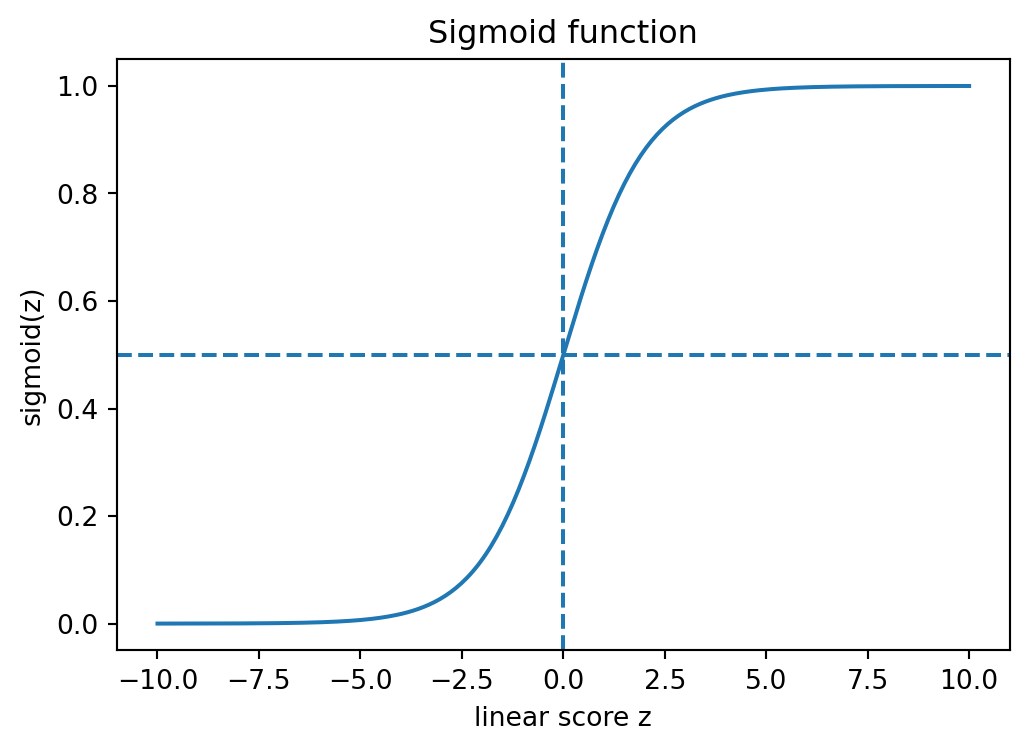

In [ ]:
# Section 5 - Sigmoid function

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

z_grid = np.linspace(-10, 10, 300)

plt.figure(figsize=(6, 4))
plt.plot(z_grid, sigmoid(z_grid))
plt.axhline(0.5, linestyle="--")
plt.axvline(0.0, linestyle="--")
plt.xlabel("linear score z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid function")
plt.show()


In [ ]:
# Section 5 - Convert arbitrary scores into probabilities

prob_example = sigmoid(scores_example)

print("First 10 scores:")
print(scores_example[:10])
print("\nFirst 10 probabilities:")
print(prob_example[:10])


First 10 scores:
[-0.2789883   0.76660836 -0.2789883   0.29027433 -0.01671054 -0.04491821
 -0.22553548 -0.2789883   0.09096722 -0.2789883 ]

First 10 probabilities:
[0.43070183 0.68278676 0.43070183 0.57206329 0.49582246 0.48877233
 0.44385392 0.43070183 0.52272614 0.43070183]


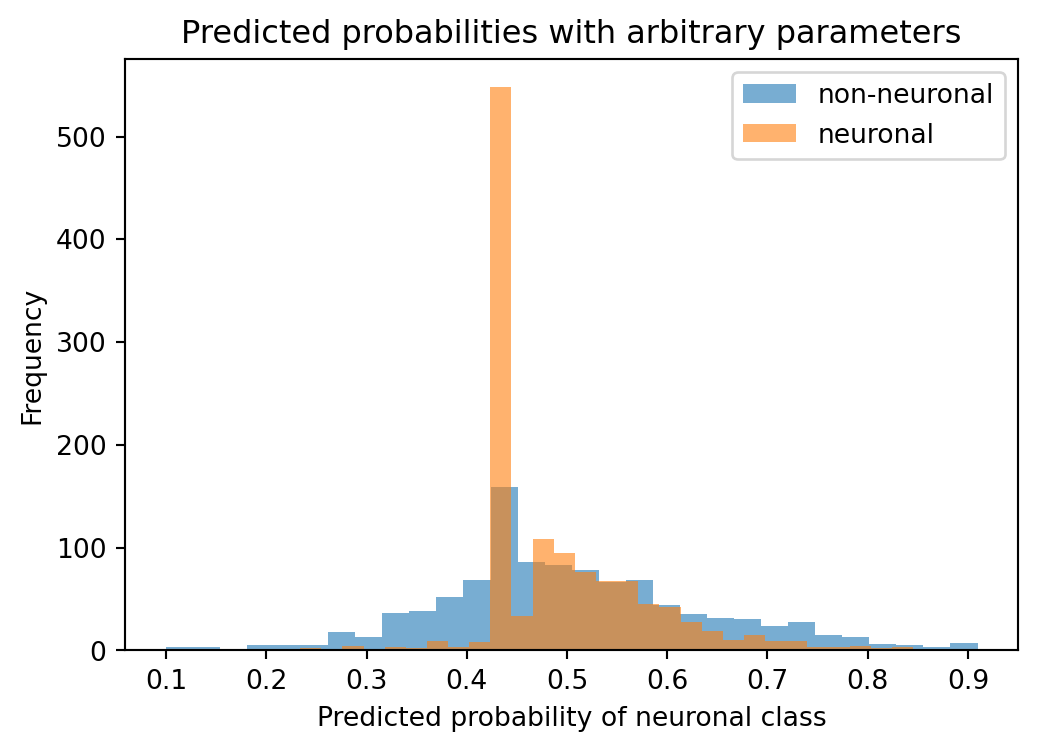

In [ ]:
# Section 5 - Visualize predicted probabilities from arbitrary parameters

plt.figure(figsize=(6, 4))
plt.hist(prob_example[y_train == 0], bins=30, alpha=0.6, label="non-neuronal")
plt.hist(prob_example[y_train == 1], bins=30, alpha=0.6, label="neuronal")
plt.xlabel("Predicted probability of neuronal class")
plt.ylabel("Frequency")
plt.title("Predicted probabilities with arbitrary parameters")
plt.legend()
plt.show()


The histogram shows the predicted probability of the neuronal class using arbitrary parameters. Many neuronal cells receive high probabilities, but some non-neuronal cells also fall in the same high-probability region, suggesting potential false positives. Since these parameters have not been learned from the data, this plot should be interpreted only as an illustration of how linear scores are transformed into probabilities by the sigmoid function.

### Exercises for Section 5

**Exercise 5.1** Compute sigmoid values for `z = -5, 0, 5`.

**Exercise 5.2** What is the value of the sigmoid function when `z = 0`?

**Exercise 5.3** Why is the sigmoid useful for binary classification?

**Exercise 5.4** What class would you predict if the predicted probability is `0.8`?


In [ ]:
# Exercises for Section 5

# Exercise 5.1 - Compute sigmoid values for z = -5, 0, 5
print("sigmoid(-5):", sigmoid(-5))
print("sigmoid(0):", sigmoid(0))
print("sigmoid(5):", sigmoid(5))


**Exercise 5.2** When `z = 0`, sigmoid(z) = 1 / (1 + e^0) = 1 / 2 = 0.5.

**Exercise 5.3** The sigmoid takes any real number and squashes it into a value between 0 and 1, so the output can be interpreted as the probability that the cell belongs to class 1.

**Exercise 5.4** We would predict class 1 (neuronal), because 0.8 is greater than the threshold 0.5.

## Section 6 — Binary Cross-Entropy loss

For logistic regression, we use Binary Cross-Entropy (BCE), also called log-loss:

$$
J(w,b) =
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(\hat{y}_i) +
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

This loss is designed to be small when the model assigns high probability to the correct class, and very large when the model is confidently wrong.


In [ ]:
# Section 6 - Binary Cross-Entropy loss

def binary_cross_entropy(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(
        y_true * np.log(y_prob) +
        (1 - y_true) * np.log(1 - y_prob)
    )

bce_example = binary_cross_entropy(y_train, prob_example)
print("Binary Cross-Entropy with arbitrary parameters:")
print(bce_example)


Binary Cross-Entropy with arbitrary parameters:
0.7340474484455093


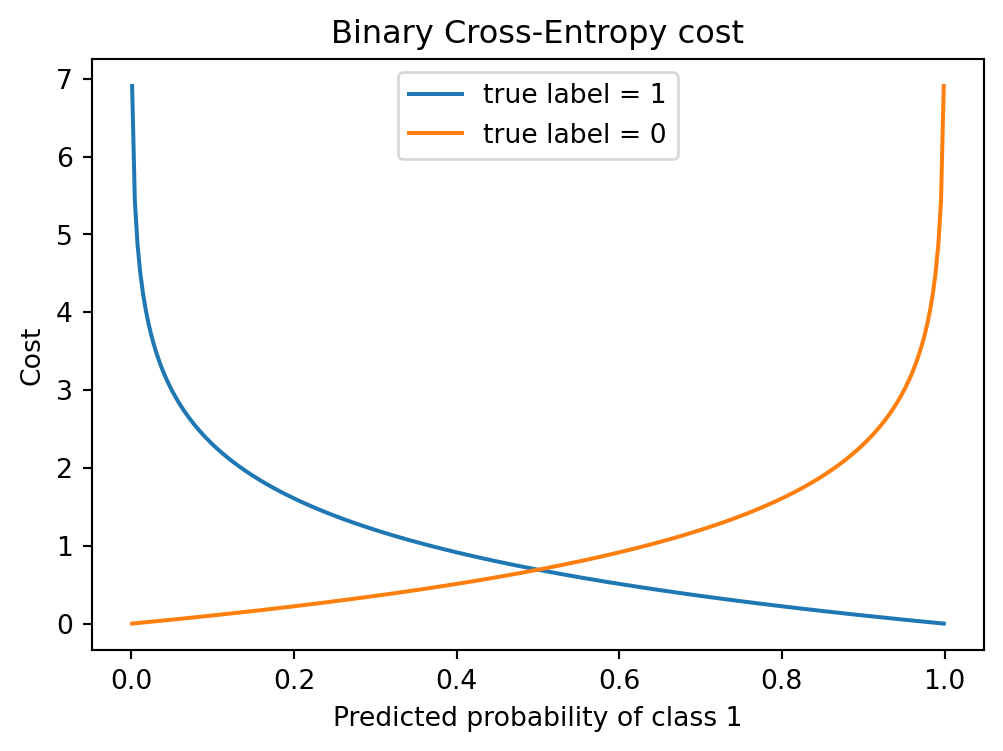

In [ ]:
# Section 6 - Visualize BCE cost for y=1 and y=0

p_grid = np.linspace(0.001, 0.999, 300)
cost_if_y1 = -np.log(p_grid)
cost_if_y0 = -np.log(1 - p_grid)

plt.figure(figsize=(6, 4))
plt.plot(p_grid, cost_if_y1, label="true label = 1")
plt.plot(p_grid, cost_if_y0, label="true label = 0")
plt.xlabel("Predicted probability of class 1")
plt.ylabel("Cost")
plt.title("Binary Cross-Entropy cost")
plt.legend()
plt.show()


The Binary Cross-Entropy (BCE) cost is low when the model assigns high probability to the correct class, and it becomes very large when the model is confidently wrong. For a true label equal to 1, the cost increases as the predicted probability of class 1 approaches 0. For a true label equal to 0, the cost increases as the predicted probability of class 1 approaches 1.

### Exercises for Section 6

**Exercise 6.1** Compute BCE for the arbitrary probabilities `prob_example`.

**Exercise 6.2** What happens to the cost when the true label is `1` but the predicted probability is close to `0`?

**Exercise 6.3** What happens to the cost when the true label is `0` but the predicted probability is close to `1`?

**Exercise 6.4** Why is BCE more appropriate than MSE for logistic regression?


In [ ]:
# Exercises for Section 6

# Exercise 6.1 - Compute BCE for the arbitrary probabilities prob_example
bce_value = binary_cross_entropy(y_train, prob_example)
print("Binary Cross-Entropy for prob_example:")
print(bce_value)


**Exercise 6.2** The cost becomes very large, because -log(0) goes to infinity. The model is being confidently wrong, so BCE punishes it heavily.

**Exercise 6.3** The cost also becomes very large, because -log(1 - 1) = -log(0) goes to infinity. Again the model is confidently wrong and BCE punishes it heavily.

**Exercise 6.4** BCE matches the probabilistic output of the sigmoid and gives very large cost when the model is confidently wrong, which gives stronger and more useful gradients for learning. MSE gives smaller gradients in those cases, so training with MSE would be slower and less effective for binary classification.

## Section 7 — Gradient Descent for logistic regression

For BCE loss, the gradients are:

$$
\frac{\partial J}{\partial w} = \frac{1}{n} X^T(\hat{y} - y)
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)
$$

This looks similar to the linear regression gradient, but now predictions are probabilities produced by the sigmoid function.


In [ ]:
# Section 7 - Logistic regression from scratch

def predict_probs(X, w, b):
    return sigmoid(X @ w + b)

def compute_logistic_gradients(X, y, w, b):
    n = X.shape[0]
    y_prob = predict_probs(X, w, b)
    error = y_prob - y
    dw = (X.T @ error) / n
    db = np.mean(error)
    return dw, db

def train_logistic_regression(X, y, learning_rate=0.1, n_steps=500):
    w = np.zeros(X.shape[1])
    b = 0.0
    loss_history = []

    for step in range(n_steps):
        y_prob = predict_probs(X, w, b)
        loss = binary_cross_entropy(y, y_prob)
        loss_history.append(loss)

        dw, db = compute_logistic_gradients(X, y, w, b)
        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, loss_history

w_fit, b_fit, loss_history = train_logistic_regression(
    X_train, y_train, learning_rate=0.1, n_steps=800
)

print("Training loss with arbitrary parameters:", bce_example)
print("Initial training loss:", loss_history[0])
print("Final training loss:", loss_history[-1])
print("First 5 fitted coefficients:", w_fit[:5])
print("Fitted bias:", b_fit)


Training loss with arbitrary parameters: 0.7340474484455093
Initial training loss: 0.6931471805599454
Final training loss: 0.030216676411638953
First 5 fitted coefficients: [-0.09288997 -0.11685138 -0.06337634 -0.05638829 -0.0753874 ]
Fitted bias: -0.3184926697542848


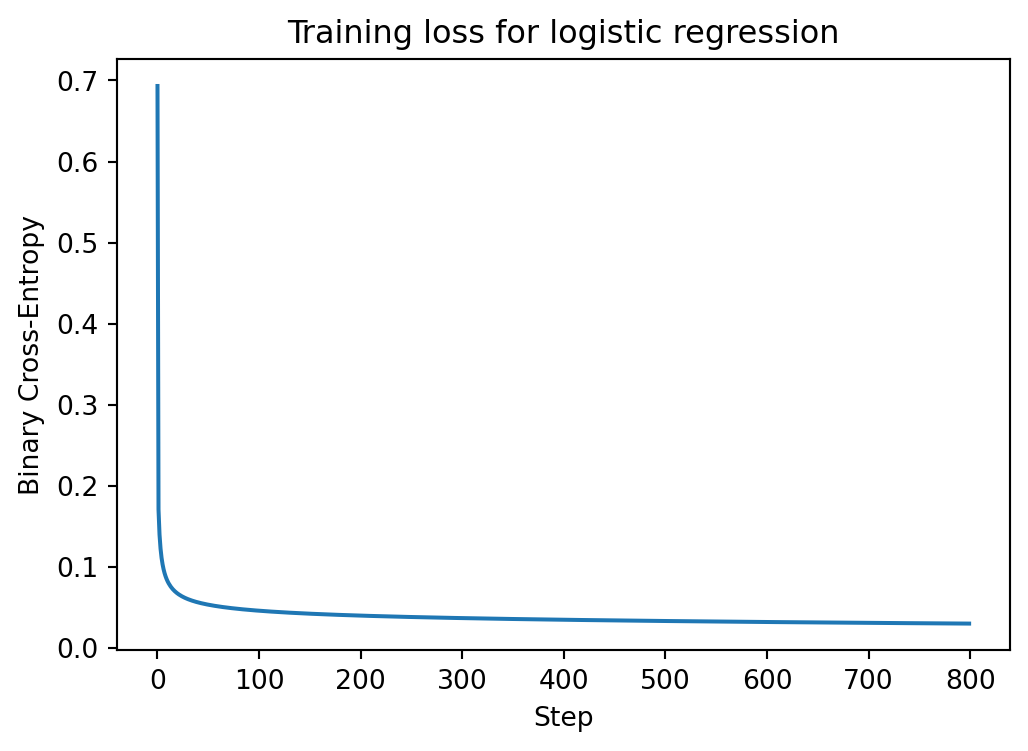

In [ ]:
# Section 7 - Plot training loss

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Step")
plt.ylabel("Binary Cross-Entropy")
plt.title("Training loss for logistic regression")
plt.show()



As in Lab 1, the training curve shows the value of the loss function during Gradient Descent (GD).

The difference is that in Lab 1 we minimized the Mean Squared Error (MSE) for a regression problem, while here we minimize the Binary Cross-Entropy (BCE) for a binary classification problem.

In both cases, the goal of Gradient Descent is the same: update the model parameters step by step to reduce the loss.

### Exercises for Section 7

**Exercise 7.1** Train logistic regression with a different learning rate.

**Exercise 7.2** Plot the training loss.

**Exercise 7.3** Does the loss decrease over time?

**Exercise 7.4** Check the shape of `w_fit`. Why does it have this shape?


In [ ]:
# Exercises for Section 7

# Exercise 7.1 - Train logistic regression with a different learning rate
w_fit2, b_fit2, loss_history2 = train_logistic_regression(
    X_train, y_train, learning_rate=0.5, n_steps=800
)

print("Initial training loss:", loss_history2[0])
print("Final training loss:", loss_history2[-1])
print("First 5 fitted coefficients:", w_fit2[:5])
print("Fitted bias:", b_fit2)

# Exercise 7.2 - Plot the training loss
plt.figure(figsize=(6, 4))
plt.plot(loss_history2)
plt.xlabel("Step")
plt.ylabel("Binary Cross-Entropy")
plt.title("Training loss with learning rate 0.5")
plt.show()

# Exercise 7.4 - Check the shape of w_fit
print("Shape of w_fit:", w_fit.shape)


**Exercise 7.3** Yes, the loss decreases over time. Each Gradient Descent step updates the weights and bias in the direction that reduces the BCE, so the loss curve goes down and then flattens out as the model converges.

**Exercise 7.4** `w_fit` has shape `(100,)` because there is one weight for each gene feature, and we have 100 gene features. The model assigns a coefficient to every input feature so it can combine all of them into a single linear score.

## Section 8 — Model evaluation for binary classification

We convert predicted probabilities into class labels using threshold 0.5:

$$
\hat{y}_{class} =
\begin{cases}
1 & \text{if } \hat{y} \geq 0.5 \\
0 & \text{if } \hat{y} < 0.5
\end{cases}
$$

We compute accuracy, confusion matrix, precision, and recall.

The **accuracy** is the fraction of cells that are correctly classified. It gives a general summary of performance, but it can be misleading when the two classes are imbalanced.

The **confusion matrix** shows the number of correct and incorrect predictions for each class. It separates true positives, true negatives, false positives, and false negatives, making it easier to understand which type of error the classifier is making.

The **precision** answers the question: among the cells predicted as neuronal, how many are truly neuronal? High precision means that the classifier produces few false positives.

The **recall** answers the question: among all truly neuronal cells, how many are correctly detected by the classifier? High recall means that the classifier produces few false negatives.


In [ ]:
# Section 8 - Classification metrics

# The `predict_class` function converts predicted probabilities into binary class predictions 
# based on a specified threshold (default is 0.5). If the predicted probability of class 1 is 
# greater than or equal to the threshold, it predicts class 1; otherwise, it predicts class 0.
def predict_class(X, w, b, threshold=0.5):
    return (predict_probs(X, w, b) >= threshold).astype(int)

# The `accuracy_score` function computes the accuracy of predictions by comparing the true labels (`y_true`) 
# with the predicted labels (`y_pred`). It returns the mean of correct predictions, which is the proportion of 
# samples that were correctly classified.
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

# The `confusion_matrix_binary` function computes the confusion matrix for binary classification. 
# It counts the number of true negatives (tn), false positives (fp), false negatives (fn), and true positives (tp)
# by comparing the true labels (`y_true`) with the predicted labels (`y_pred`). The function returns a 2x2 NumPy 
# array representing the confusion matrix.
def confusion_matrix_binary(y_true, y_pred):
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[tn, fp], [fn, tp]])

# The `precision_score` function calculates the precision of the binary classification by using the confusion matrix.
# Precision is defined as the ratio of true positives (tp) to the sum of true positives and false positives (fp).
# A small constant (1e-12) is added to the denominator to avoid division by zero when there are no positive predictions.
def precision_score(y_true, y_pred):
    cm = confusion_matrix_binary(y_true, y_pred)
    tp = cm[1, 1]
    fp = cm[0, 1]
    return tp / (tp + fp + 1e-12)

# The `recall_score` function calculates the recall of the binary classification by using the confusion matrix.
# Recall is defined as the ratio of true positives (tp) to the sum of true positives and false negatives (fn).
# A small constant (1e-12) is added to the denominator to avoid division by zero when there are no true positives.
def recall_score(y_true, y_pred):
    cm = confusion_matrix_binary(y_true, y_pred)
    tp = cm[1, 1]
    fn = cm[1, 0]
    return tp / (tp + fn + 1e-12)


In [ ]:
# Section 8 - Evaluate train and test performance

y_train_pred = predict_class(X_train, w_fit, b_fit)
y_test_pred = predict_class(X_test, w_fit, b_fit)

print("Training accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))
print("Test precision:", precision_score(y_test, y_test_pred))
print("Test recall:", recall_score(y_test, y_test_pred))

cm_test = confusion_matrix_binary(y_test, y_test_pred)


Training accuracy: 0.9875776397515528
Test accuracy: 0.9840213049267643
Test precision: 0.9782082324455181
Test recall: 0.9926289926289902


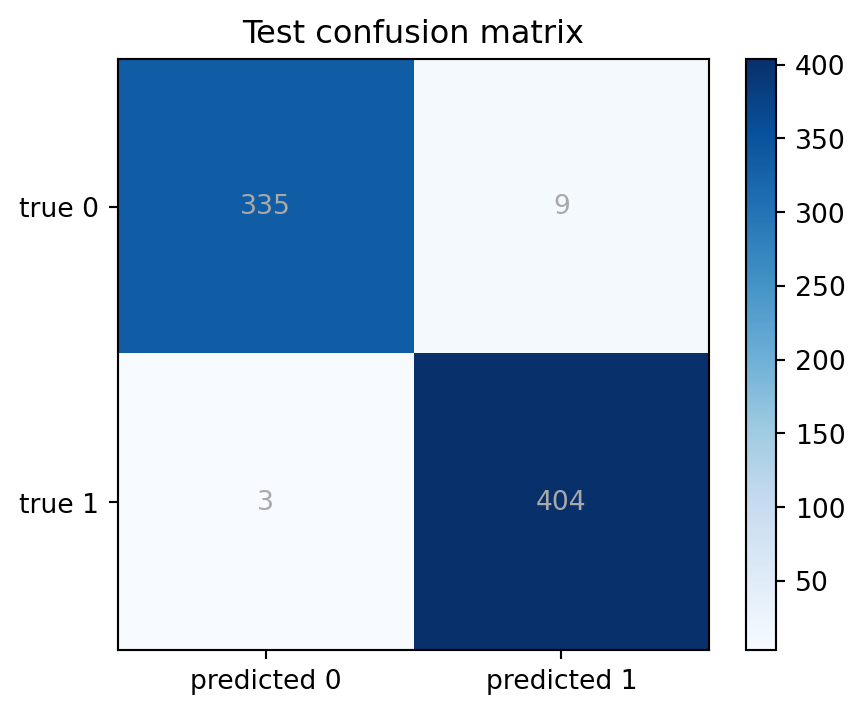

In [ ]:
# Section 8 - Plot confusion matrix

plt.figure(figsize=(5, 4))
plt.imshow(cm_test, cmap="Blues")
plt.xticks([0, 1], ["predicted 0", "predicted 1"])
plt.yticks([0, 1], ["true 0", "true 1"])
plt.title("Test confusion matrix")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_test[i, j], ha="center", va="center", color="darkgrey")

plt.show()


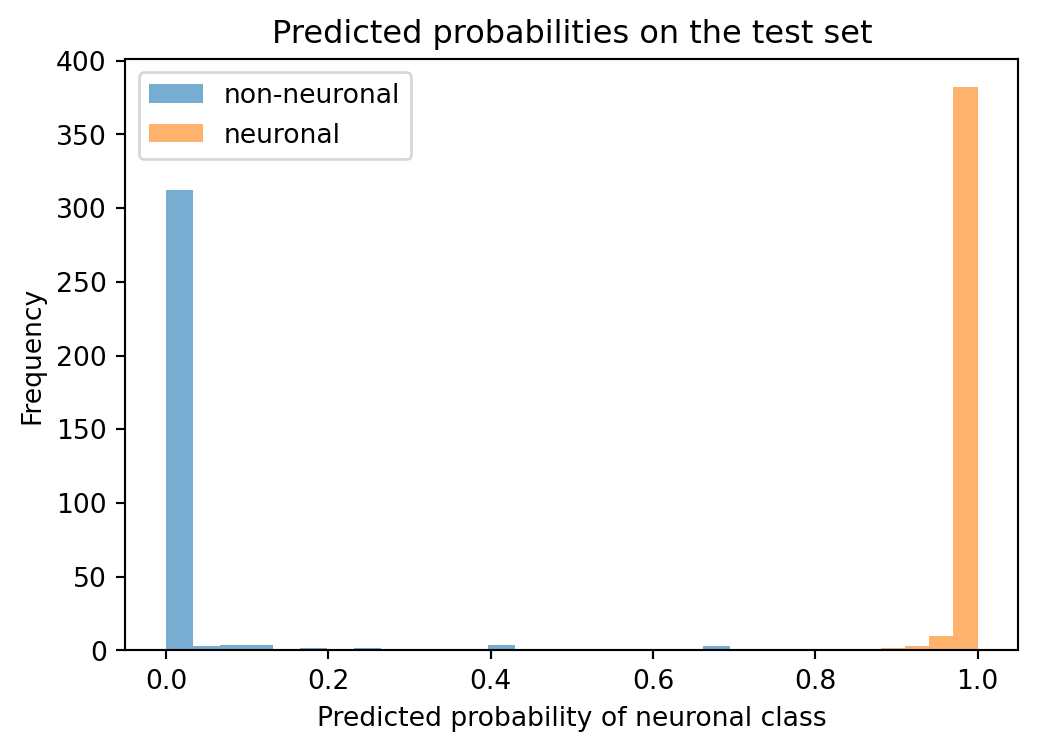

In [ ]:
# Section 8 - Predicted probability distributions on the test set

test_prob = predict_probs(X_test, w_fit, b_fit)

plt.figure(figsize=(6, 4))
plt.hist(test_prob[y_test == 0], bins=30, alpha=0.6, label="non-neuronal")
plt.hist(test_prob[y_test == 1], bins=30, alpha=0.6, label="neuronal")
plt.xlabel("Predicted probability of neuronal class")
plt.ylabel("Frequency")
plt.title("Predicted probabilities on the test set")
plt.legend()
plt.show()


This plot shows the distribution of predicted probabilities for the two true classes in the test set. It complements the confusion matrix because it shows how confident the classifier is, not only whether the final class prediction is correct. Here, most non-neuronal cells receive probabilities close to 0, while most neuronal cells receive probabilities close to 1, indicating a strong separation between the two classes. Cells near 0.5 would represent uncertain cases close to the decision threshold.

### Exercises for Section 8

**Exercise 8.1** Compute accuracy on the training set and on the test set.

**Exercise 8.2** Compute the confusion matrix on the test set.

**Exercise 8.3** Explain what false positives and false negatives mean in this biological task.

**Exercise 8.4** Is accuracy alone sufficient to understand classifier performance?


In [ ]:
# Exercises for Section 8

# Exercise 8.1 - Accuracy on training and test sets
y_train_pred = predict_class(X_train, w_fit, b_fit)
y_test_pred = predict_class(X_test, w_fit, b_fit)

print("Training accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_test_pred))

# Exercise 8.2 - Confusion matrix on the test set
cm_test = confusion_matrix_binary(y_test, y_test_pred)
print("\nConfusion matrix on the test set:")
print(cm_test)


**Exercise 8.3** In this biological task, a **false positive** is a non-neuronal cell that the model predicts as neuronal (true label 0, predicted 1). A **false negative** is a neuronal cell that the model predicts as non-neuronal (true label 1, predicted 0). False positives mean the classifier is calling cells "neuronal" when they are not, and false negatives mean the classifier is missing real neuronal cells.

**Exercise 8.4** No, accuracy alone is not sufficient. If the two classes are imbalanced, a model can reach a high accuracy just by predicting the majority class, while still missing most of the minority class. The confusion matrix, precision, and recall give a more complete picture by separating the two types of error.

## Section 9 — Decision boundary in two dimensions

The full model uses many genes, so its decision boundary is a hyperplane in high-dimensional space. To visualize the idea, we train a logistic regression model using only two genes.


In [ ]:
# Section 9 - Train logistic regression on two selected genes

X_train_2d = X_train[:, [gene_a, gene_b]]
X_test_2d = X_test[:, [gene_a, gene_b]]

w_2d, b_2d, loss_2d = train_logistic_regression(
    X_train_2d, y_train, learning_rate=0.1, n_steps=800
)

print("2D model weights:", w_2d)
print("2D model bias:", b_2d)


2D model weights: [-1.24667364 -0.88691381]
2D model bias: -0.056714028716005595


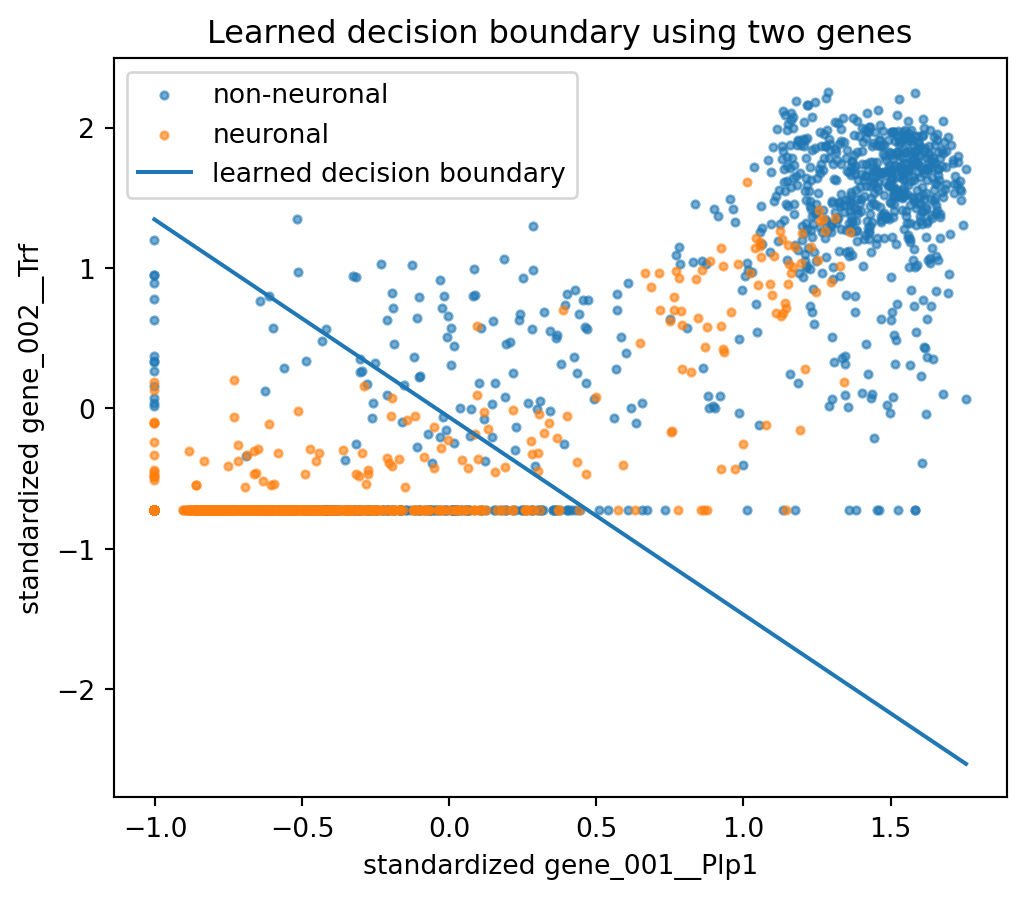

In [ ]:
# Section 9 - Plot learned decision boundary

plt.figure(figsize=(6, 5))
plt.scatter(X_train_2d[y_train == 0, 0], X_train_2d[y_train == 0, 1], s=8, alpha=0.6, label="non-neuronal")
plt.scatter(X_train_2d[y_train == 1, 0], X_train_2d[y_train == 1, 1], s=8, alpha=0.6, label="neuronal")

x_values = np.linspace(X_train_2d[:, 0].min(), X_train_2d[:, 0].max(), 100)
if abs(w_2d[1]) > 1e-12:
    y_boundary = -(w_2d[0] * x_values + b_2d) / w_2d[1]
    plt.plot(x_values, y_boundary, label="learned decision boundary")

plt.xlabel(f"standardized {gene_columns[gene_a]}")
plt.ylabel(f"standardized {gene_columns[gene_b]}")
plt.title("Learned decision boundary using two genes")
plt.legend()
plt.show()


### Exercises for Section 9

**Exercise 9.1** Train a two-gene classifier using a different pair of genes.

**Exercise 9.2** Plot the corresponding decision boundary.

**Exercise 9.3** Why can the full model perform better than the two-gene model?


In [ ]:
# Exercises for Section 9

# Exercise 9.1 - Train a two-gene classifier with a different pair of genes
gene_c = 4
gene_d = 5

X_train_2d_new = X_train[:, [gene_c, gene_d]]
X_test_2d_new = X_test[:, [gene_c, gene_d]]

w_2d_new, b_2d_new, loss_2d_new = train_logistic_regression(
    X_train_2d_new, y_train, learning_rate=0.1, n_steps=800
)

print("2D model weights:", w_2d_new)
print("2D model bias:", b_2d_new)

# Exercise 9.2 - Plot the corresponding decision boundary
plt.figure(figsize=(6, 5))
plt.scatter(X_train_2d_new[y_train == 0, 0], X_train_2d_new[y_train == 0, 1], s=8, alpha=0.6, label="non-neuronal")
plt.scatter(X_train_2d_new[y_train == 1, 0], X_train_2d_new[y_train == 1, 1], s=8, alpha=0.6, label="neuronal")

x_values = np.linspace(X_train_2d_new[:, 0].min(), X_train_2d_new[:, 0].max(), 100)
if abs(w_2d_new[1]) > 1e-12:
    y_boundary = -(w_2d_new[0] * x_values + b_2d_new) / w_2d_new[1]
    plt.plot(x_values, y_boundary, label="learned decision boundary")

plt.xlabel(f"standardized {gene_columns[gene_c]}")
plt.ylabel(f"standardized {gene_columns[gene_d]}")
plt.title("Learned decision boundary using a different pair of genes")
plt.legend()
plt.show()


**Exercise 9.3** The full model can perform better than the two-gene model because it has access to all 100 gene features and can combine information from many genes at the same time. Two genes alone usually cannot fully separate neuronal from non-neuronal cells, but when many informative genes are combined, their small individual contributions add up and the decision boundary becomes much more accurate.

## Section 10 — L2 regularization

When a model has many features, it can overfit the training data. Regularization reduces overfitting by penalizing large coefficients.

L2 regularization adds a penalty proportional to the sum of squared weights. This discourages very large coefficients, making the model simpler and less prone to overfitting, while still allowing all features to contribute to the prediction.

For logistic regression with L2 regularization, the objective becomes:


$$
J(w,b) = \mathrm{BCE}(w,b) + \underbrace{\frac{\lambda}{2n}\sum_{j=1}^{p} w_j^2}_{\text{L2 regularization}}
$$

We regularize the weights `w`, but not the bias `b`.

Here we define the functions needed for implementing the logistic regression with L2 regularization.


In [ ]:
# Section 10 - Regularized logistic regression functions

def binary_cross_entropy_l2(y_true, y_prob, w, lambda_reg=0.0):
    bce = binary_cross_entropy(y_true, y_prob)
    l2_penalty = (lambda_reg / (2 * len(y_true))) * np.sum(w ** 2)
    return bce + l2_penalty

def compute_logistic_gradients_l2(X, y, w, b, lambda_reg=0.0):
    n = X.shape[0]
    y_prob = predict_probs(X, w, b)
    error = y_prob - y
    dw = (X.T @ error) / n
    db = np.mean(error)
    dw = dw + (lambda_reg / n) * w
    return dw, db

def train_logistic_regression_l2(X, y, learning_rate=0.1, n_steps=500, lambda_reg=0.0):
    w = np.zeros(X.shape[1])
    b = 0.0
    loss_history = []

    for step in range(n_steps):
        y_prob = predict_probs(X, w, b)
        loss = binary_cross_entropy_l2(y, y_prob, w, lambda_reg=lambda_reg)
        loss_history.append(loss)
        dw, db = compute_logistic_gradients_l2(X, y, w, b, lambda_reg=lambda_reg)
        w = w - learning_rate * dw
        b = b - learning_rate * db

    return w, b, loss_history


Here we train the same logistic regression model several times, changing only the L2 regularization strength `lambda_reg`. For each model, we record training accuracy, test accuracy, and the L2 norm of the coefficient vector. This lets us check whether stronger regularization reduces coefficient magnitude and whether this affects predictive performance.

In [ ]:
# Section 10 - Train models with different regularization strengths

lambda_values = [0.0, 0.01, 0.1, 1.0, 10.0]
regularization_results = []

for lambda_reg in lambda_values:
    w_reg, b_reg, hist_reg = train_logistic_regression_l2(
        X_train, y_train, learning_rate=0.1, n_steps=800, lambda_reg=lambda_reg
    )

    y_train_pred_reg = predict_class(X_train, w_reg, b_reg)
    y_test_pred_reg = predict_class(X_test, w_reg, b_reg)

    regularization_results.append({
        "lambda": lambda_reg,
        "w": w_reg,
        "b": b_reg,
        "loss_history": hist_reg,
        "train_accuracy": accuracy_score(y_train, y_train_pred_reg),
        "test_accuracy": accuracy_score(y_test, y_test_pred_reg),
        "coef_norm": np.sqrt(np.sum(w_reg ** 2))
    })

results_df = pd.DataFrame([
    {"lambda": r["lambda"], "train_accuracy": r["train_accuracy"],
     "test_accuracy": r["test_accuracy"], "coef_norm": r["coef_norm"]}
    for r in regularization_results
])

display(results_df)


,lambda,train_accuracy,test_accuracy,coef_norm
0,0.00,0.987578,0.984021,1.777559
1,0.01,0.987578,0.984021,1.777307
2,0.10,0.987578,0.984021,1.775046
3,1.00,0.987578,0.984021,1.752837
4,10.00,0.988465,0.984021,1.566018


In this dataset, increasing L2 regularization reduces the magnitude of the coefficients while keeping classification performance almost unchanged. This suggests that the model can remain accurate with smaller, more regularized weights.

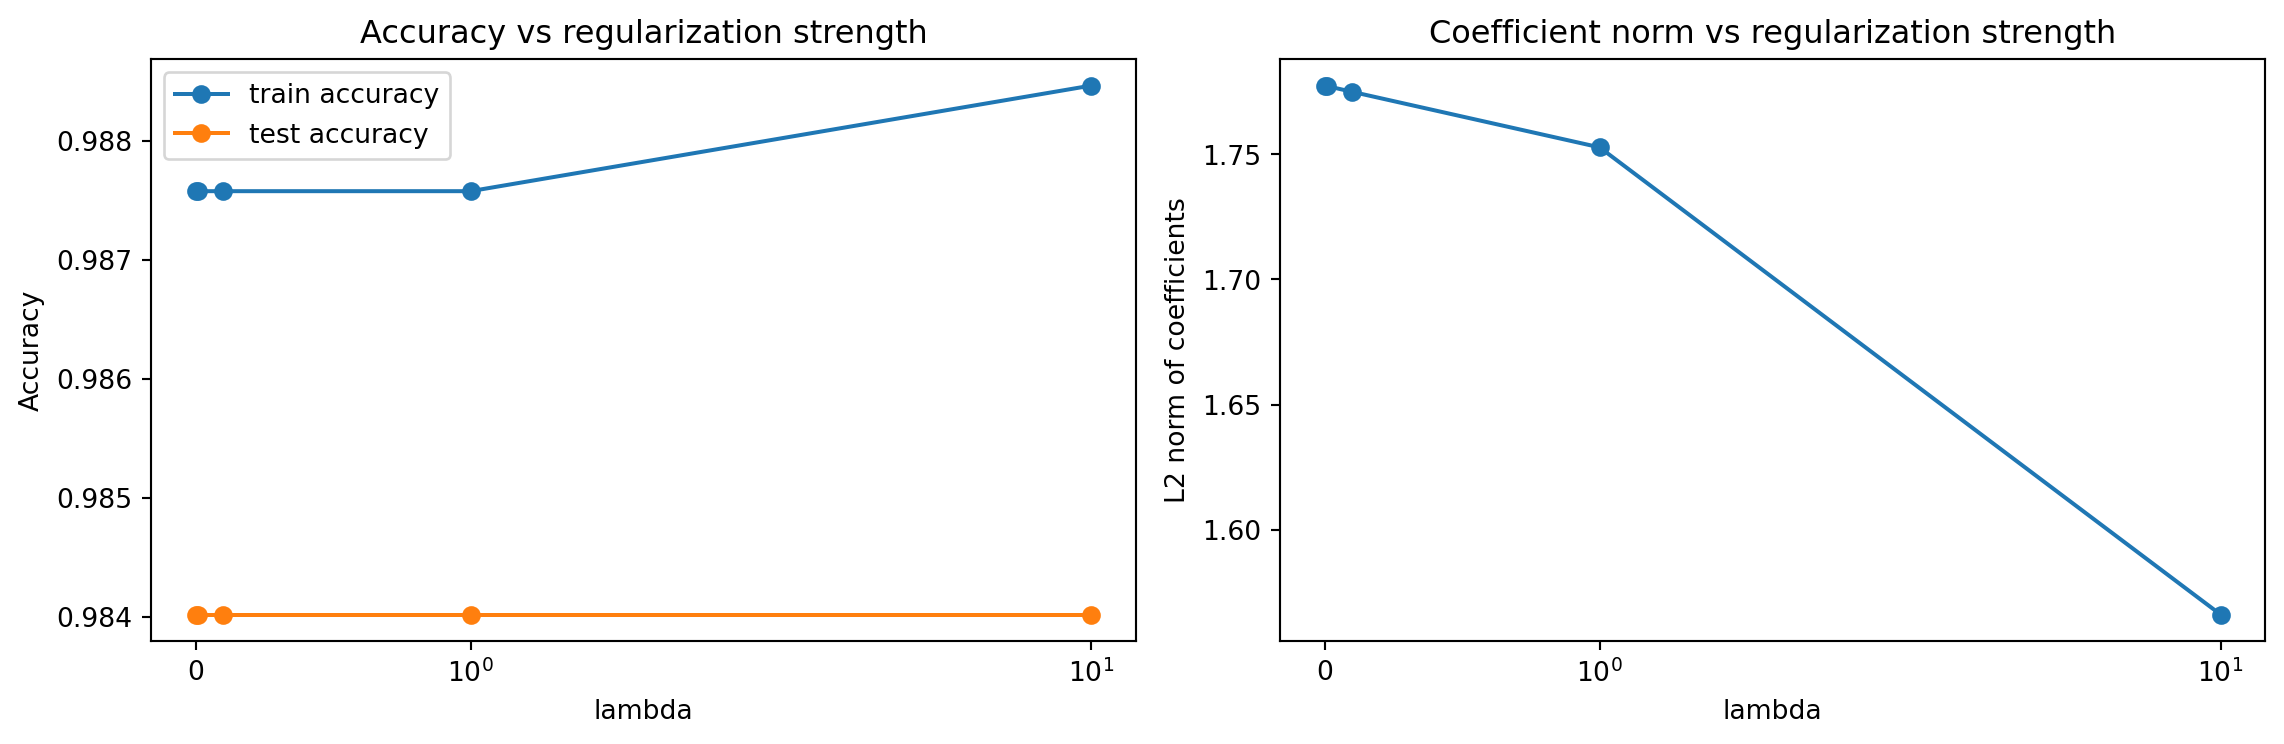

In [ ]:
# Section 10 - Visualize effect of regularization side by side

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    results_df["lambda"],
    results_df["train_accuracy"],
    marker="o",
    label="train accuracy"
)
axes[0].plot(
    results_df["lambda"],
    results_df["test_accuracy"],
    marker="o",
    label="test accuracy"
)
axes[0].set_xscale("symlog")
axes[0].set_xlabel("lambda")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs regularization strength")
axes[0].legend()

axes[1].plot(
    results_df["lambda"],
    results_df["coef_norm"],
    marker="o"
)
axes[1].set_xscale("symlog")
axes[1].set_xlabel("lambda")
axes[1].set_ylabel("L2 norm of coefficients")
axes[1].set_title("Coefficient norm vs regularization strength")

plt.tight_layout()
plt.show()


The first plot shows that training and test accuracy remain almost unchanged across the tested values of `lambda`. This means that, in this dataset, stronger L2 regularization does not substantially affect classification performance.

The second plot shows the expected effect of L2 regularization: as `lambda` increases, the L2 norm of the coefficient vector decreases. In other words, the model keeps a similar predictive performance while using smaller coefficients, which corresponds to a simpler and more regularized solution.

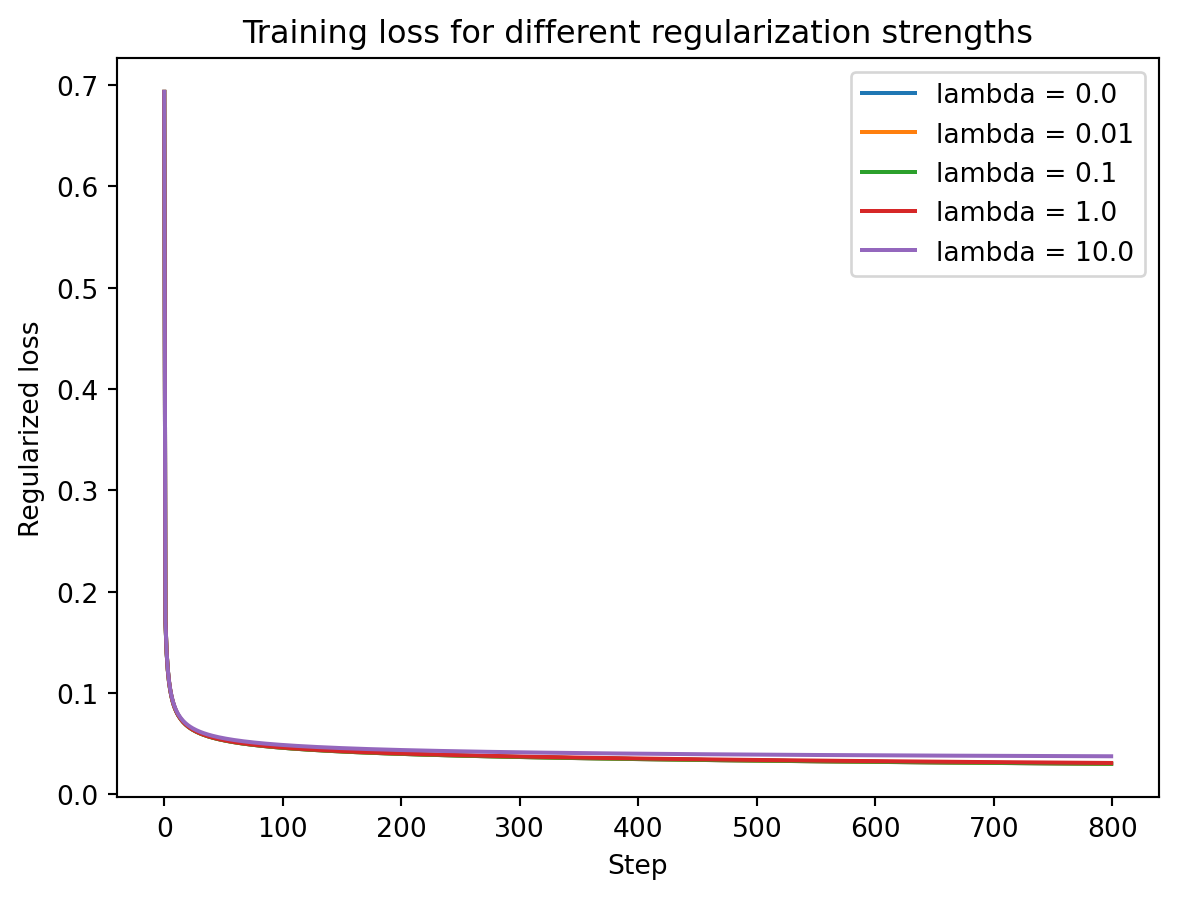

In [ ]:
# Section 10 - Compare loss curves for different regularization strengths

plt.figure(figsize=(7, 5))

for result in regularization_results:
    plt.plot(result["loss_history"], label=f"lambda = {result['lambda']}")

plt.xlabel("Step")
plt.ylabel("Regularized loss")
plt.title("Training loss for different regularization strengths")
plt.legend()
plt.show()


The loss curves decrease rapidly during the first iterations and then approach a plateau, indicating that Gradient Descent (GD) is effectively optimizing the model. The curves for different values of `lambda` are almost overlapping, suggesting that the tested levels of L2 regularization do not substantially change the optimization dynamics in this dataset. However, the loss shown here is the regularized objective, so larger values of `lambda` include a stronger penalty on large coefficients.


### Exercises for Section 10

**Exercise 10.1** Train logistic regression with `lambda_reg = 0.0`, `0.1`, and `10.0`.

**Exercise 10.2** Compare training accuracy and test accuracy.

**Exercise 10.3** Compare the L2 norm of the coefficient vector.

**Exercise 10.4** What happens when regularization becomes very strong?

**Exercise 10.5** Why do we regularize the weights but not the bias?


In [ ]:
# Exercises for Section 10

# Exercise 10.1 - Train logistic regression with lambda_reg = 0.0, 0.1, and 10.0
lambda_list = [0.0, 0.1, 10.0]

for lambda_reg in lambda_list:
    w_reg, b_reg, hist_reg = train_logistic_regression_l2(
        X_train, y_train, learning_rate=0.1, n_steps=800, lambda_reg=lambda_reg
    )

    # Exercise 10.2 - Compare training accuracy and test accuracy
    y_train_pred_reg = predict_class(X_train, w_reg, b_reg)
    y_test_pred_reg = predict_class(X_test, w_reg, b_reg)
    train_acc = accuracy_score(y_train, y_train_pred_reg)
    test_acc = accuracy_score(y_test, y_test_pred_reg)

    # Exercise 10.3 - Compare the L2 norm of the coefficient vector
    coef_norm = np.sqrt(np.sum(w_reg ** 2))

    print("lambda_reg =", lambda_reg)
    print("  Training accuracy:", train_acc)
    print("  Test accuracy:", test_acc)
    print("  L2 norm of weights:", coef_norm)
    print()


**Exercise 10.4** When regularization becomes very strong, the weights are pushed close to zero. The model becomes too simple and starts underfitting, because it cannot use the gene features enough to separate the two classes, so accuracy drops.

**Exercise 10.5** We regularize the weights but not the bias because the bias only shifts the decision boundary up or down. It does not control how strongly any feature is used, so penalizing it would not reduce overfitting, it would just make the model less able to match the overall class balance in the data.

## Section 11 — Biological interpretation of coefficients

A positive coefficient means that higher expression of that gene pushes the model toward the neuronal class.

A negative coefficient means that higher expression of that gene pushes the model toward the non-neuronal class.

Important caution: coefficients indicate associations used by the classifier. They do not prove causal biological roles.


In [ ]:
# Section 11 - Select a regularized model for interpretation

selected_lambda = 0.1
selected_result = [r for r in regularization_results if r["lambda"] == selected_lambda][0]

w_selected = selected_result["w"]
b_selected = selected_result["b"]

print("Selected lambda:", selected_lambda)
print("Selected model test accuracy:", selected_result["test_accuracy"])


Selected lambda: 0.1
Selected model test accuracy: 0.9840213049267643


In [ ]:
# Section 11 - Inspect top positive and negative coefficients

n_top = 10
sorted_indices = np.argsort(w_selected)

top_negative_idx = sorted_indices[:n_top]
top_positive_idx = sorted_indices[-n_top:][::-1]

print("Top positive coefficients:")
for idx in top_positive_idx:
    print(gene_columns[idx], w_selected[idx])

print("\nTop negative coefficients:")
for idx in top_negative_idx:
    print(gene_columns[idx], w_selected[idx])


Top positive coefficients:
gene_096__Rasgrp1 0.3569316728365826
gene_022__Stmn3 0.3510404320012726
gene_052__Stmn2 0.3412718438730482
gene_088__Grm5 0.33449727585653166
gene_064__Ndrg4 0.33006795935200495
gene_059__Nsf 0.3115287518511134
gene_062__Atp1a3 0.2973962368041895
gene_068__Cck 0.2960011489330444
gene_056__Gria1 0.2939474794624373
gene_079__Ntm 0.2906850131807659

Top negative coefficients:
gene_049__Sparc -0.5337759704437903
gene_045__Sepp1 -0.3256226487779861
gene_034__Sparcl1 -0.2905382064682281
gene_077__Itm2a -0.29037031734350377
gene_037__Dbi -0.2881813682170868
gene_054__Sept4 -0.2200829321245422
gene_081__Npc2 -0.2111794880528988
gene_019__Atp1a2 -0.17742866343601957
gene_015__Apoe -0.15848142825089453
gene_075__Cmtm5 -0.15315730423022228


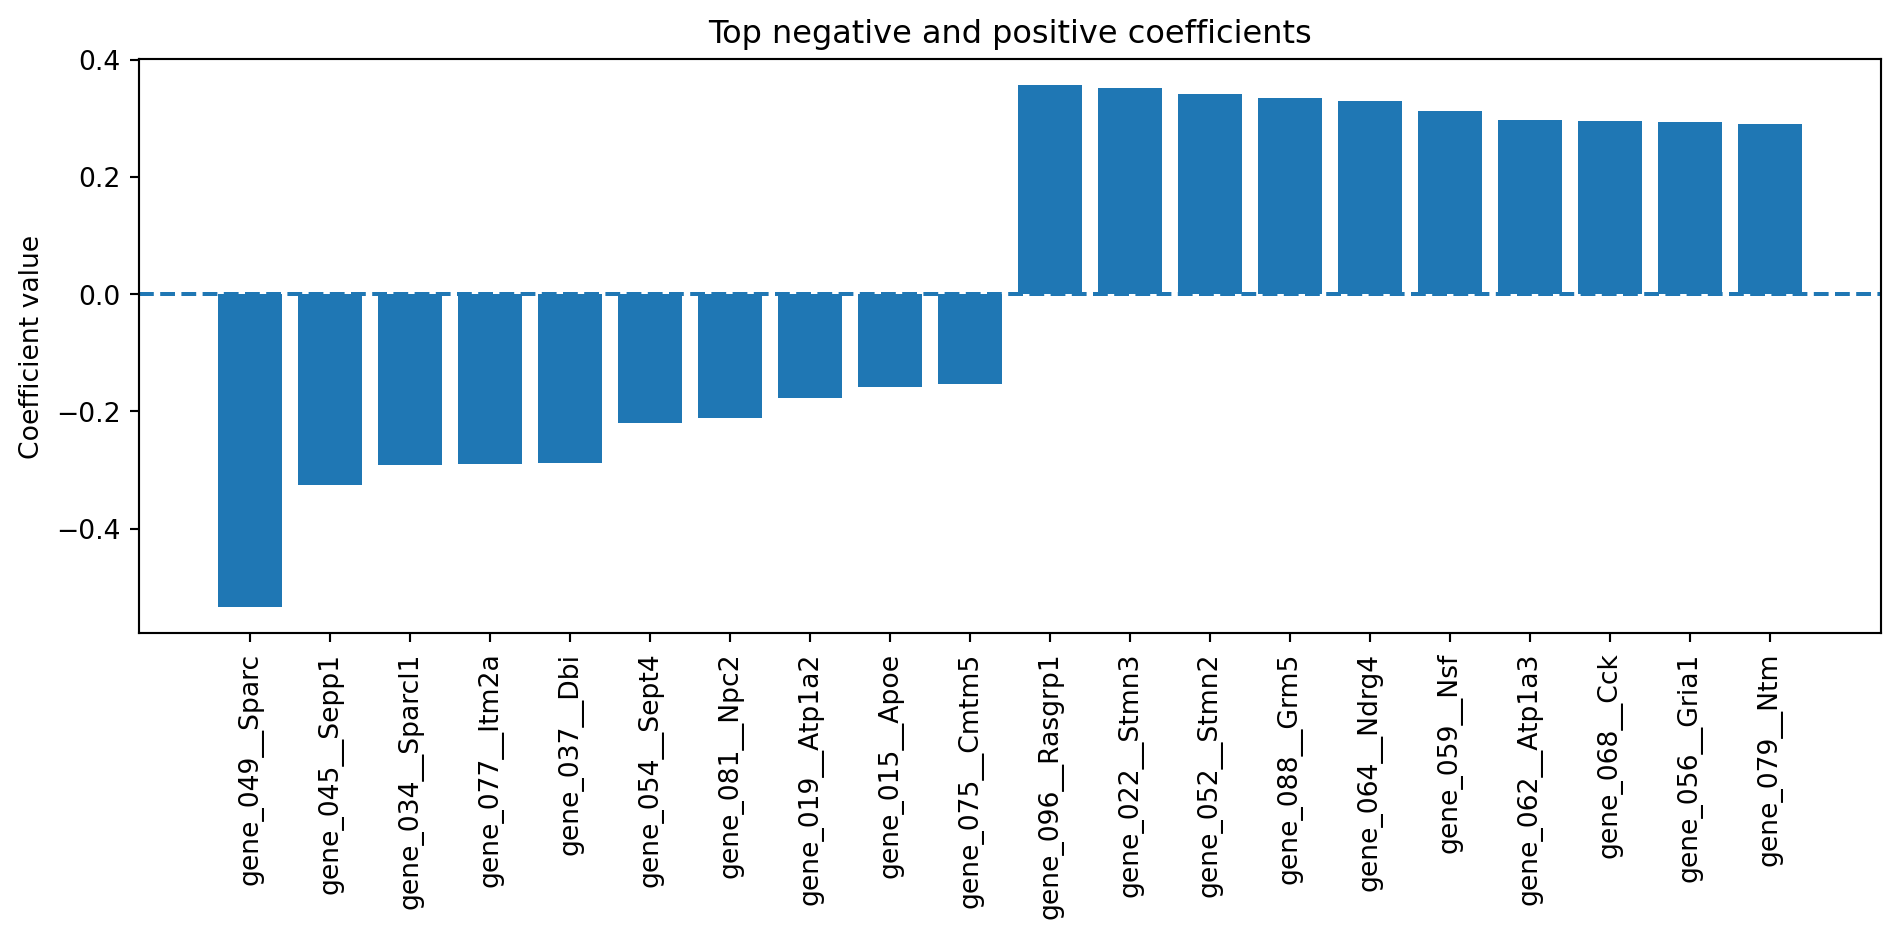

In [ ]:
# Section 11 - Plot top coefficients

top_idx = np.concatenate([top_negative_idx, top_positive_idx])
top_names = [gene_columns[idx] for idx in top_idx]
top_values = w_selected[top_idx]

plt.figure(figsize=(10, 5))
plt.bar(range(len(top_values)), top_values)
plt.xticks(range(len(top_values)), top_names, rotation=90)
plt.axhline(0, linestyle="--")
plt.ylabel("Coefficient value")
plt.title("Top negative and positive coefficients")
plt.tight_layout()
plt.show()


### Exercises for Section 11

**Exercise 11.1** Identify the top 5 positive coefficients.

**Exercise 11.2** Identify the top 5 negative coefficients.

**Exercise 11.3** What does a positive coefficient mean in this biological task?

**Exercise 11.4** What does a negative coefficient mean in this biological task?

**Exercise 11.5** Why should we avoid interpreting coefficients as causal effects?


In [ ]:
# Exercises for Section 11

# Exercise 11.1 - Identify the top 5 positive coefficients
# Exercise 11.2 - Identify the top 5 negative coefficients
n_top = 5
sorted_indices = np.argsort(w_selected)

top_negative_idx = sorted_indices[:n_top]
top_positive_idx = sorted_indices[-n_top:][::-1]

print("Top 5 positive coefficients:")
for idx in top_positive_idx:
    print(gene_columns[idx], w_selected[idx])

print("
Top 5 negative coefficients:")
for idx in top_negative_idx:
    print(gene_columns[idx], w_selected[idx])


**Exercise 11.3** A positive coefficient means that higher expression of that gene makes the model more likely to predict the neuronal class. In other words, that gene is associated with neuronal cells in the dataset.

**Exercise 11.4** A negative coefficient means that higher expression of that gene makes the model more likely to predict the non-neuronal class. That gene is associated with non-neuronal cells in the dataset.

**Exercise 11.5** We should avoid interpreting coefficients as causal effects because the model only learns associations between gene expression and the class label. A gene with a large coefficient is informative for the classifier, but that does not prove the gene causes the cell to be neuronal or non-neuronal. The gene could be correlated with another underlying biological process, and proving causality requires controlled experiments, not just observational data.

## Section 12 — Final recap and submission

In this lab, we:

- loaded a real biological classification dataset
- represented gene expression data as a machine learning matrix
- explored class balance and gene expression distributions
- introduced linear classifiers
- used the sigmoid function to produce probabilities
- implemented logistic regression from scratch using NumPy
- optimized BCE loss with GD
- evaluated a binary classifier
- added L2 regularization
- inspected gene coefficients biologically

## Final reflection questions

1. What is the difference between a regression target and a classification label?
2. Why do we use the sigmoid function in logistic regression?
3. What does the output of logistic regression represent?
4. Why is BCE appropriate for binary classification?
5. Why can regularization improve generalization?
6. What does a positive gene coefficient mean in this model?
7. What is the difference between association and causality?



## Final reflection answers

**1. What is the difference between a regression target and a classification label?**

A regression target is a continuous number (any real value), like the gene expression value we predicted in Lab 1. A classification label is a discrete category, like 0 or 1 for non-neuronal or neuronal in this lab.

**2. Why do we use the sigmoid function in logistic regression?**

The sigmoid takes the linear score, which can be any real number, and squashes it into a value between 0 and 1. This way the output can be interpreted as a probability instead of just a raw score.

**3. What does the output of logistic regression represent?**

The output represents the predicted probability that a cell belongs to class 1 (the neuronal class in this lab). If the probability is greater than or equal to 0.5, we predict class 1, otherwise class 0.

**4. Why is BCE appropriate for binary classification?**

BCE gives a small cost when the predicted probability is close to the true label and a very large cost when the model is confidently wrong. It also gives strong gradients during training, which makes Gradient Descent work well with the sigmoid output.

**5. Why can regularization improve generalization?**

Regularization penalizes large weights, so the model stays simpler and does not memorize noise in the training data. A simpler model is usually less overfit and performs better on new unseen data.

**6. What does a positive gene coefficient mean in this model?**

A positive coefficient means that higher expression of that gene makes the model more likely to predict the neuronal class. The gene is associated with neuronal cells in the dataset.

**7. What is the difference between association and causality?**

Association means two things tend to happen together in the data, while causality means one actually causes the other. The model only learns associations from the gene expression data, so a large coefficient does not prove the gene causes the cell type. Proving causality requires controlled biological experiments.